# UAV Flight Deviation — Exploration Notebook
Sanity-check the raw data: parse one desired KML path, one actual flight log, one weather CSV, compute cross-track deviation, and visualize.

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

DATA = '/Users/abdulazizal-haidary/development/Machine Learning/Project/Data/extracted'
FLIGHTS = os.path.join(DATA, 'Flight_path_for_UAV_correction')
WEATHER = os.path.join(DATA, 'Weather data', 'Weather Data')
DESIRED_MASTER = os.path.join(FLIGHTS, 'Desired_flight_path_soil_moisture_Research_plot.kml')
print(os.path.exists(DESIRED_MASTER))

True


## 1. Parse the desired flight path (master KML)

In [2]:
NS = {'k': 'http://www.opengis.net/kml/2.2'}

def parse_kml_waypoints(path):
    tree = ET.parse(path)
    root = tree.getroot()
    pts = []
    for coord in root.iter('{http://www.opengis.net/kml/2.2}coordinates'):
        for token in coord.text.strip().split():
            parts = token.split(',')
            if len(parts) >= 2:
                lon, lat = float(parts[0]), float(parts[1])
                alt = float(parts[2]) if len(parts) > 2 else np.nan
                pts.append((lat, lon, alt))
    return pd.DataFrame(pts, columns=['lat', 'lon', 'alt'])

desired = parse_kml_waypoints(DESIRED_MASTER)
print('waypoints:', len(desired))
desired.head()

waypoints: 81


,lat,lon,alt
0,33.165600,-81.134748,54.00
1,33.165674,-81.136218,154.28
2,33.165564,-81.136218,154.28
3,33.164949,-81.136218,154.28
4,33.164839,-81.136218,154.28


## 2. Parse one actual flight log
Filter out the controller's pre-flight home (Paris default) by bounding-box around the SC plot.

In [3]:
FLIGHT_TXT = os.path.join(FLIGHTS, 'Flight 1_11_7_25', 'flightpath_15_48_Pika_L_11_7_25.txt')
actual = pd.read_csv(FLIGHT_TXT, sep='\t')
actual.columns = [c.strip() for c in actual.columns]
print('rows raw:', len(actual))

# bbox around the desired path (drops pre-takeoff Paris-default rows)
pad = 0.01  # ~1 km
lat_min, lat_max = desired.lat.min() - pad, desired.lat.max() + pad
lon_min, lon_max = desired.lon.min() - pad, desired.lon.max() + pad
in_bbox = ((actual.Latitude.between(lat_min, lat_max)) &
           (actual.Longitude.between(lon_min, lon_max)))
actual = actual[in_bbox].copy()

# IMPORTANT: the recorder's Time column is NOT a real Unix epoch (controller clock unset).
# Anchor to the date+time encoded in the filename and use Time as elapsed seconds.
fn = os.path.basename(FLIGHT_TXT)
m = re.search(r'(\d{1,2})_(\d{2})_.*?(\d{1,2})_(\d{1,2})_(\d{2})\.txt$', fn)
hh, mm, mo, d, yy = map(int, m.groups())
anchor = pd.Timestamp(year=2000 + yy, month=mo, day=d, hour=hh, minute=mm, tz='US/Eastern')
actual['ts'] = anchor + pd.to_timedelta(actual['Time'] - actual['Time'].iloc[0], unit='s')
print('rows in-mission:', len(actual), '| anchor:', anchor)
actual[['ts', 'Latitude', 'Longitude', 'Altitude']].head()

rows raw: 2507
rows in-mission: 2475 | anchor: 2025-11-07 15:48:00-05:00


,ts,Latitude,Longitude,Altitude
32,2025-11-07 15:48:00-05:00,33.165441,-81.135303,65.058139
33,2025-11-07 15:48:01-05:00,33.165441,-81.135303,65.076597
34,2025-11-07 15:48:02-05:00,33.165441,-81.135303,65.096984
35,2025-11-07 15:48:03-05:00,33.165441,-81.135303,65.081340
36,2025-11-07 15:48:04-05:00,33.165441,-81.135303,65.095232


## 3. Cross-track deviation
Convert (lat, lon) → local meters via equirectangular projection centered on plot, then for each actual point compute the perpendicular distance to the nearest segment of the desired polyline.

In [4]:
R = 6371000.0  # earth radius (m)
lat0 = np.deg2rad(desired.lat.mean())
lon0 = np.deg2rad(desired.lon.mean())

def to_xy(lat, lon):
    lat_r = np.deg2rad(lat); lon_r = np.deg2rad(lon)
    x = R * (lon_r - lon0) * np.cos(lat0)
    y = R * (lat_r - lat0)
    return x, y

dx, dy = to_xy(desired.lat.values, desired.lon.values)
ax, ay = to_xy(actual.Latitude.values, actual.Longitude.values)

def cross_track(px, py, sx, sy):
    """For each point (px, py), distance to nearest segment in polyline (sx, sy)."""
    min_d = np.full(px.shape, np.inf)
    for i in range(len(sx) - 1):
        x1, y1, x2, y2 = sx[i], sy[i], sx[i+1], sy[i+1]
        vx, vy = x2 - x1, y2 - y1
        L2 = vx*vx + vy*vy
        if L2 == 0:
            d = np.hypot(px - x1, py - y1)
        else:
            t = ((px - x1)*vx + (py - y1)*vy) / L2
            t = np.clip(t, 0, 1)
            cx = x1 + t*vx; cy = y1 + t*vy
            d = np.hypot(px - cx, py - cy)
        min_d = np.minimum(min_d, d)
    return min_d

actual['deviation_m'] = cross_track(ax, ay, dx, dy)
actual['deviation_m'].describe()

count    2475.000000
mean        4.290932
std         3.358714
min         0.003144
25%         1.432571
50%         2.019854
75%         7.930018
max         8.706497
Name: deviation_m, dtype: float64

## 4. Plot actual vs desired path

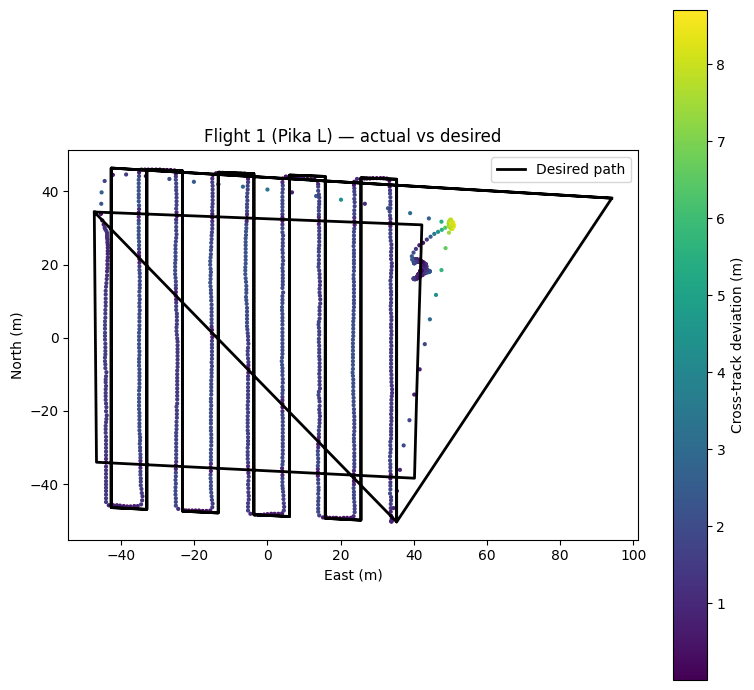

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(dx, dy, '-', color='black', lw=2, label='Desired path', zorder=3)
sc = ax.scatter(to_xy(actual.Latitude.values, actual.Longitude.values)[0],
                to_xy(actual.Latitude.values, actual.Longitude.values)[1],
                c=actual.deviation_m, s=4, cmap='viridis')
plt.colorbar(sc, label='Cross-track deviation (m)')
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
ax.set_title('Flight 1 (Pika L) — actual vs desired')
ax.set_aspect('equal'); ax.legend(); plt.tight_layout()
plt.savefig('/Users/abdulazizal-haidary/development/Machine Learning/Project/_explore_path.png', dpi=110)
plt.show()

## 5. Load matching weather CSV

In [6]:
WX = os.path.join(WEATHER, 'Weather_F1_ Pika_GE_11_7_25.csv')
wx = pd.read_csv(WX)
wx['ts'] = pd.to_datetime(wx['Timestamp (EST)'], utc=True).dt.tz_convert('US/Eastern')
wx = wx.sort_values('ts').reset_index(drop=True)
print('weather rows:', len(wx), '| span:', wx.ts.min(), '->', wx.ts.max())
print('flight span:', actual.ts.min(), '->', actual.ts.max())
wx[['ts', 'WS_ms', 'WindDir', 'AirTC', 'RH']].head()

weather rows: 12 | span: 2025-11-07 11:10:00-05:00 -> 2025-11-07 12:05:00-05:00
flight span: 2025-11-07 15:48:00-05:00 -> 2025-11-07 16:29:15-05:00


,ts,WS_ms,WindDir,AirTC,RH
0,2025-11-07 11:10:00-05:00,1.96588,203.426400,21.96177,66.17595
1,2025-11-07 11:15:00-05:00,0.03332,324.235600,22.02500,65.65491
2,2025-11-07 11:20:00-05:00,2.96548,336.037600,22.35403,64.09019
3,2025-11-07 11:25:00-05:00,1.53272,4.796602,22.42010,63.43899
4,2025-11-07 11:30:00-05:00,5.23124,239.831500,22.60858,62.78004


## 6. Join weather to flight (asof merge on timestamp)

In [7]:
actual_sorted = actual.sort_values('ts')
merged = pd.merge_asof(actual_sorted, wx[['ts', 'WS_ms', 'WindDir', 'AirTC', 'RH', 'BP_mbar']],
                       on='ts', direction='nearest', tolerance=pd.Timedelta('10min'))
print('merged rows:', len(merged), '| with weather:', merged.WS_ms.notna().sum())
merged[['ts', 'deviation_m', 'WS_ms', 'WindDir']].head()

merged rows: 2475 | with weather: 0


,ts,deviation_m,WS_ms,WindDir
0,2025-11-07 15:48:00-05:00,0.550078,NaN,NaN
1,2025-11-07 15:48:01-05:00,0.550078,NaN,NaN
2,2025-11-07 15:48:02-05:00,0.550078,NaN,NaN
3,2025-11-07 15:48:03-05:00,0.550078,NaN,NaN
4,2025-11-07 15:48:04-05:00,0.550078,NaN,NaN


## 7. Quick wind vs deviation sanity check

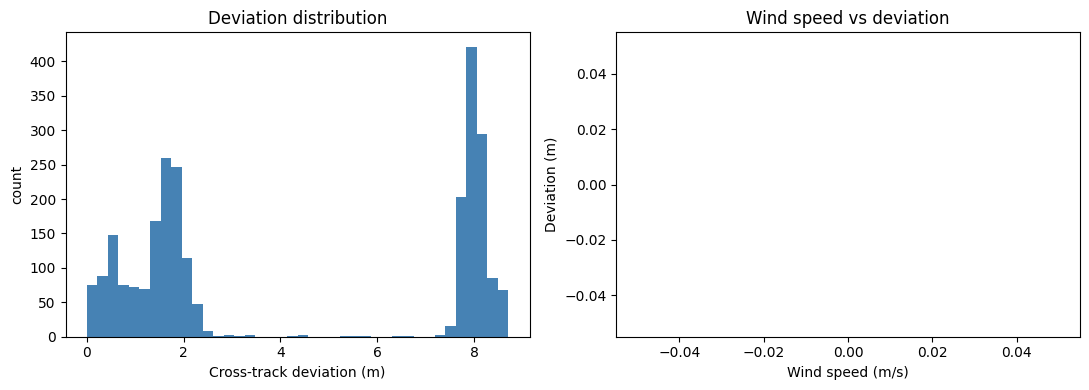

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(merged.deviation_m.dropna(), bins=40, color='steelblue')
axes[0].set_xlabel('Cross-track deviation (m)'); axes[0].set_ylabel('count')
axes[0].set_title('Deviation distribution')
axes[1].scatter(merged.WS_ms, merged.deviation_m, s=4, alpha=0.5)
axes[1].set_xlabel('Wind speed (m/s)'); axes[1].set_ylabel('Deviation (m)')
axes[1].set_title('Wind speed vs deviation')
plt.tight_layout()
plt.savefig('/Users/abdulazizal-haidary/development/Machine Learning/Project/_explore_wind.png', dpi=110)
plt.show()